# Exploratory Data Analysis — Inside Airbnb London

**City:** London | **Snapshot:** 2025-09-14 | **Currency:** GBP  
**Data source:** `data/processed/london/` (cleaned + enriched Parquet files)

## Business questions this notebook answers

1. How are prices distributed, and which boroughs / room types command a premium?
2. Where are listings concentrated geographically?
3. How do hosts segment (casual vs professional) and how does it affect price and quality?
4. What does review activity signal about demand?
5. Is there seasonal or weekday/weekend variation in availability?
6. Are there unusual listings (very long stays, very high price, inactive)?
7. What is the relationship between review score, response rate, and occupancy proxy?

> **A-005 constraint:** `calendar.price` and `calendar.adjusted_price` are 100 % NULL in this snapshot.  
> All temporal analyses use **availability** and **occupancy proxy** instead of price.

---
## Step 1 — Load and verify the data

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Paths ────────────────────────────────────────────────────────────────────
PROCESSED = Path("../data/processed/london")
RAW       = Path("../data/raw/london")
FIGS      = Path("../reports/figures/eda")
TABLES    = Path("../reports/tables")

# Output directories (created here so later cells never fail on missing dir)
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
# Consistent, clean look for all charts
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

SNAPSHOT_DATE = pd.Timestamp("2025-09-14")
CITY_LABEL    = "London"

In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
# listing_master = one row per listing, all derived metrics already joined
listings = pd.read_parquet(PROCESSED / "listing_master.parquet")

# calendar = one row per (listing, date) — 35M rows; load only needed columns
# to avoid exhausting RAM. calendar_clean.parquet has no price column (A-005).
calendar = pd.read_parquet(
    PROCESSED / "calendar_clean.parquet",
    columns=["listing_id", "date", "available", "minimum_nights", "maximum_nights"],
)
# Derive numeric flag: 1 = available, 0 = blocked/booked
calendar["available_int"] = calendar["available"].astype(int)

# reviews = one row per review, 2.1M rows
reviews = pd.read_parquet(PROCESSED / "reviews_clean.parquet")

# neighbourhood_summary = 33 boroughs, pre-aggregated metrics
neigh_sum = pd.read_parquet(PROCESSED / "neighbourhood_summary.parquet")

print(f"listings  : {listings.shape[0]:>9,} rows × {listings.shape[1]} cols")
print(f"calendar  : {calendar.shape[0]:>9,} rows × {calendar.shape[1]} cols")
print(f"reviews   : {reviews.shape[0]:>9,} rows × {reviews.shape[1]} cols")
print(f"neigh_sum : {neigh_sum.shape[0]:>9,} rows × {neigh_sum.shape[1]} cols")

listings  :    96,871 rows × 100 cols
calendar  : 35,357,974 rows × 6 cols
reviews   : 2,097,996 rows × 8 cols
neigh_sum :        33 rows × 12 cols


In [3]:
# ── Uniqueness and null guards ────────────────────────────────────────────────
# These must hold before any analysis. If they raise, stop and investigate.
assert listings["id"].is_unique,       "listing id not unique — data issue"
assert not listings["id"].isna().any(), "listing id has nulls — data issue"

print("Uniqueness checks passed")

Uniqueness checks passed


In [4]:
# ── Key column overview ───────────────────────────────────────────────────────
# Quick look at the numeric columns that drive the rest of the EDA
key_cols = [
    "price_numeric",        # nightly price in GBP (NULL for 36% of listings)
    "accommodates",         # guest capacity
    "bedrooms",             # bedroom count
    "bathroom_count",       # parsed from bathrooms_text
    "minimum_nights",       # host-set minimum stay
    "availability_365",     # days open per year (from listings snapshot)
    "number_of_reviews",    # total reviews ever
    "reviews_per_month_calc",  # computed rate over active months
    "review_scores_rating", # overall rating (0–5 scale in this data)
    "host_tenure_years",    # years since host joined
    "host_portfolio_size",  # number of listings this host has
    "occupancy_proxy",      # 1 − availability_rate (calendar-based)
    "revenue_proxy_gbp",    # price_numeric × unavailable_days (upper bound)
]

listings[key_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price_numeric,61963.0,229.92,4437.59,7.00,30.00,40.00,77.00,135.00,221.00,500.00,1100.00,1085147.00
accommodates,96871.0,3.33,2.08,1.00,1.00,1.00,2.00,2.00,4.00,7.00,10.00,16.00
bedrooms,84096.0,1.61,1.04,0.00,0.00,1.00,1.00,1.00,2.00,4.00,5.00,50.00
bathroom_count,96718.0,1.33,0.68,0.00,0.50,1.00,1.00,1.00,1.50,2.50,3.50,30.00
minimum_nights,96871.0,5.44,23.69,1.00,1.00,1.00,1.00,2.00,4.00,14.00,90.00,1125.00
availability_365,96871.0,144.93,141.81,0.00,0.00,0.00,0.00,96.00,288.00,364.00,365.00,365.00
number_of_reviews,96871.0,21.66,50.37,0.00,0.00,0.00,1.00,5.00,20.00,98.00,246.00,1902.00
reviews_per_month_calc,72749.0,0.64,1.11,0.00,0.00,0.00,0.00,0.17,0.75,2.92,5.33,32.50
review_scores_rating,72749.0,4.68,0.49,0.00,2.50,4.00,4.58,4.83,5.00,5.00,5.00,5.00
host_tenure_years,96830.0,7.64,3.89,0.01,0.27,0.91,4.06,8.57,10.58,13.20,14.30,17.05


In [5]:
# ── Missingness summary for key columns ──────────────────────────────────────
miss = (
    listings[key_cols]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
miss["missing_pct"] = (miss["missing_count"] / len(listings) * 100).round(1)

print(miss.to_string())

                        missing_count  missing_pct
price_numeric                   34908         36.0
accommodates                        0          0.0
bedrooms                        12775         13.2
bathroom_count                    153          0.2
minimum_nights                      0          0.0
availability_365                    0          0.0
number_of_reviews                   0          0.0
reviews_per_month_calc          24122         24.9
review_scores_rating            24122         24.9
host_tenure_years                  41          0.0
host_portfolio_size                 0          0.0
occupancy_proxy                     0          0.0
revenue_proxy_gbp               34908         36.0


In [6]:
# ── Categorical field overview ────────────────────────────────────────────────
cat_cols = ["room_type", "property_type_bucket", "neighbourhood_cleansed"]
for col in cat_cols:
    print(f"\n{col} ({listings[col].nunique()} unique):")
    print(listings[col].value_counts().head(10).to_string())


room_type (4 unique):
room_type
entire_home     62907
private_room    33643
shared_room       212
hotel_room        109

property_type_bucket (5 unique):
property_type_bucket
apartment    69713
house        24244
hotel         2107
other          615
unique         192

neighbourhood_cleansed (33 unique):
neighbourhood_cleansed
Westminster               11385
Tower Hamlets              7469
Camden                     6551
Kensington and Chelsea     6401
Hackney                    6359
Southwark                  5475
Lambeth                    5190
Islington                  5036
Wandsworth                 4965
Hammersmith and Fulham     4157


In [7]:
# ── Calendar data sanity ──────────────────────────────────────────────────────
# Confirm A-005: calendar price is absent from this parquet (only 4 cols loaded)
# available_int = 1 means available, 0 means blocked/booked
print("Calendar date range:",
      calendar["date"].min(), "→", calendar["date"].max())
print("available_int values:",
      calendar["available_int"].value_counts().to_dict())
print("Unique listing IDs in calendar:",
      calendar["listing_id"].nunique())

Calendar date range: 2025-09-14 00:00:00 → 2026-09-17 00:00:00


available_int values: {0: 21313866, 1: 14044108}


Unique listing IDs in calendar: 96871


In [8]:
# ── Reviews data sanity ───────────────────────────────────────────────────────
print("Reviews date range:",
      reviews["date"].min(), "→", reviews["date"].max())
print("Unique listings with reviews:",
      reviews["listing_id"].nunique())
print("Reviews columns:", list(reviews.columns))

Reviews date range: 2009-12-21 00:00:00 → 2025-09-17 00:00:00
Unique listings with reviews: 72749
Reviews columns: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'comment_length', 'comment_is_duplicate']


In [9]:
# ── Save full numerical summary to CSV ───────────────────────────────────────
# This CSV backs the 'Summary Statistics' section of eda_findings.md
summary = listings[key_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T.round(4)
summary["missing_count"] = listings[key_cols].isna().sum()
summary["missing_pct"]   = (listings[key_cols].isna().mean() * 100).round(1)
summary.to_csv(TABLES / "numerical_summary.csv")

print("Saved → reports/tables/numerical_summary.csv")

Saved → reports/tables/numerical_summary.csv


In [10]:
# ── Analysis population: price-eligible listings ──────────────────────────────
# Keep only listings with a valid, non-negative price.
# This subset is used for all price-related charts.
# Non-price analyses (availability, reviews) use the full `listings` DataFrame.
eda = listings[
    listings["price_numeric"].notna()
    & listings["price_numeric"].ge(0)
].copy()

# Document the exclusions clearly
excl = pd.DataFrame([
    {"rule": "total_listings",         "count": len(listings)},
    {"rule": "missing_price",          "count": int(listings["price_numeric"].isna().sum())},
    {"rule": "negative_price",         "count": int((listings["price_numeric"] < 0).sum())},
    {"rule": "price_eligible_population", "count": len(eda)},
])
excl.to_csv(TABLES / "population_exclusions.csv", index=False)

print(excl.to_string(index=False))
print(f"\nPrice-eligible coverage: {len(eda)/len(listings)*100:.1f}% of all listings")

                     rule  count
           total_listings  96871
            missing_price  34908
           negative_price      0
price_eligible_population  61963

Price-eligible coverage: 64.0% of all listings


---
## Step 2 — Summary statistics and distributions

Covers: price distribution, price by room type / property type / neighbourhood,
host portfolio, review scores, and availability bands.

All price charts use the `eda` subset (61,963 listings with valid price).
Non-price charts (reviews, availability) use the full `listings` DataFrame.

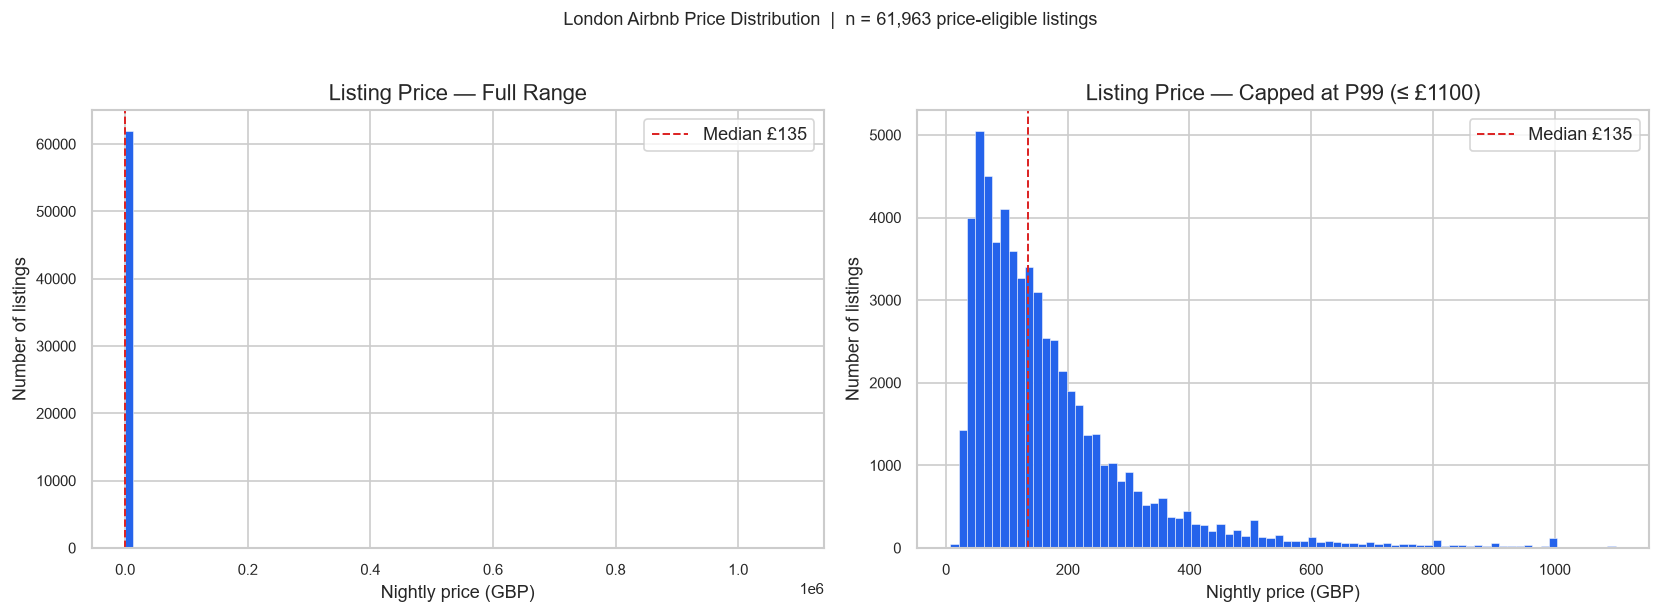

Median price   : £135
Mean price     : £230  (skewed up by luxury tail)
P99 cutoff     : £1100
Listings > P99 : 613  (excluded only from visual, kept in data)


In [11]:
# ── Charts 1 & 2 — Price distribution (full and P99-capped) ──────────────────
# Two side-by-side views: full range reveals the luxury tail;
# capped view shows where 99% of listings actually sit.

p99 = eda["price_numeric"].quantile(0.99)
p50 = eda["price_numeric"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eda["price_numeric"], bins=80, color="#2563eb", edgecolor="white", linewidth=0.3)
axes[0].axvline(p50, color="#dc2626", linestyle="--", linewidth=1.2, label=f"Median £{p50:.0f}")
axes[0].set_title("Listing Price — Full Range")
axes[0].set_xlabel("Nightly price (GBP)")
axes[0].set_ylabel("Number of listings")
axes[0].legend()

# Cap at P99 so the bulk of the distribution is readable
axes[1].hist(eda.loc[eda["price_numeric"] <= p99, "price_numeric"],
             bins=80, color="#2563eb", edgecolor="white", linewidth=0.3)
axes[1].axvline(p50, color="#dc2626", linestyle="--", linewidth=1.2, label=f"Median £{p50:.0f}")
axes[1].set_title(f"Listing Price — Capped at P99 (≤ £{p99:.0f})")
axes[1].set_xlabel("Nightly price (GBP)")
axes[1].set_ylabel("Number of listings")
axes[1].legend()

plt.suptitle(f"London Airbnb Price Distribution  |  n = {len(eda):,} price-eligible listings",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Business interpretation
print(f"Median price   : £{p50:.0f}")
print(f"Mean price     : £{eda['price_numeric'].mean():.0f}  (skewed up by luxury tail)")
print(f"P99 cutoff     : £{p99:.0f}")
print(f"Listings > P99 : {(eda['price_numeric'] > p99).sum():,}  (excluded only from visual, kept in data)")

C:\Users\Bavikaran\AppData\Local\Temp\ipykernel_16932\4175460262.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


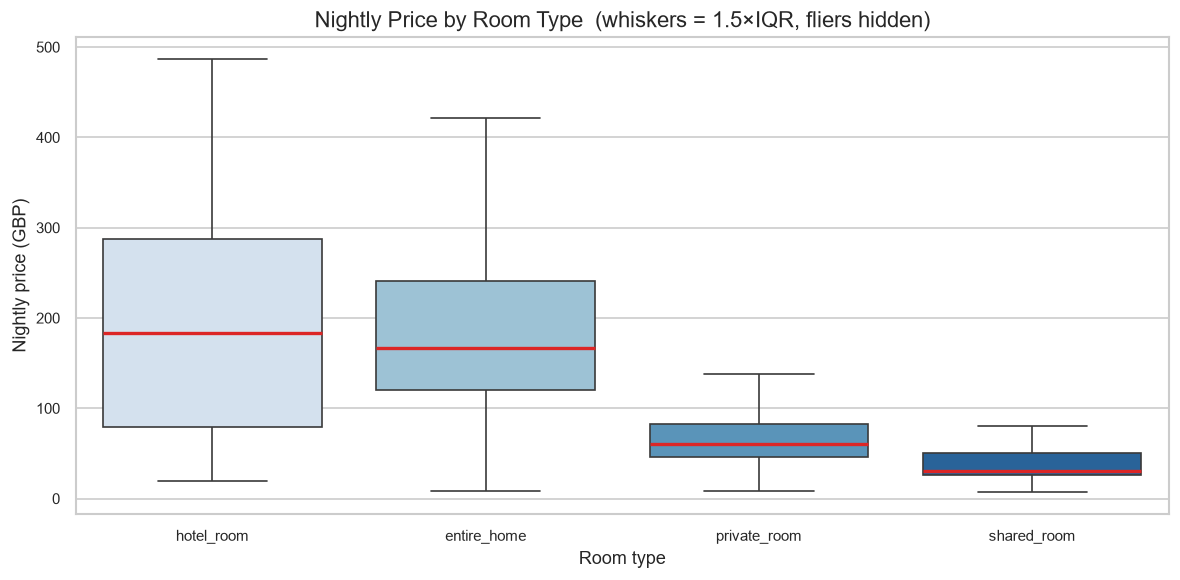

              listing_count  median_price  mean_price    p25    p75     p95
room_type                                                                  
hotel_room               72         281.0       658.0  112.0  925.0  1490.0
entire_home           42318         175.0       279.0  122.0  266.0   574.0
private_room          19382          61.0       122.0   46.0   85.0   192.0
shared_room             191          32.0        97.0   26.0   56.0   318.0


In [12]:
# ── Chart 3 — Price by room type ─────────────────────────────────────────────
# Box plots without outliers so the inter-quartile range is readable.
# showfliers=False keeps the chart clean; we report P95 in the table instead.

price_by_room = (
    eda.groupby("room_type")["price_numeric"]
    .agg(
        listing_count="count",
        median_price="median",
        mean_price="mean",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
    )
    .sort_values("median_price", ascending=False)
    .round(0)
)
price_by_room.to_csv(TABLES / "price_by_room_type.csv")

# Ordered by median price (highest first)
room_order = price_by_room.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

# seaborn boxplot supports order= natively; cap y-axis at P95 for readability
sns.boxplot(
    data=eda[eda["price_numeric"] <= eda["price_numeric"].quantile(0.95)],
    x="room_type",
    y="price_numeric",
    order=room_order,
    ax=ax,
    showfliers=False,
    palette="Blues",
    medianprops={"color": "#dc2626", "linewidth": 2},
)
ax.set_title("Nightly Price by Room Type  (whiskers = 1.5×IQR, fliers hidden)")
ax.set_xlabel("Room type")
ax.set_ylabel("Nightly price (GBP)")
plt.tight_layout()
plt.savefig(FIGS / "02_price_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_room.to_string())

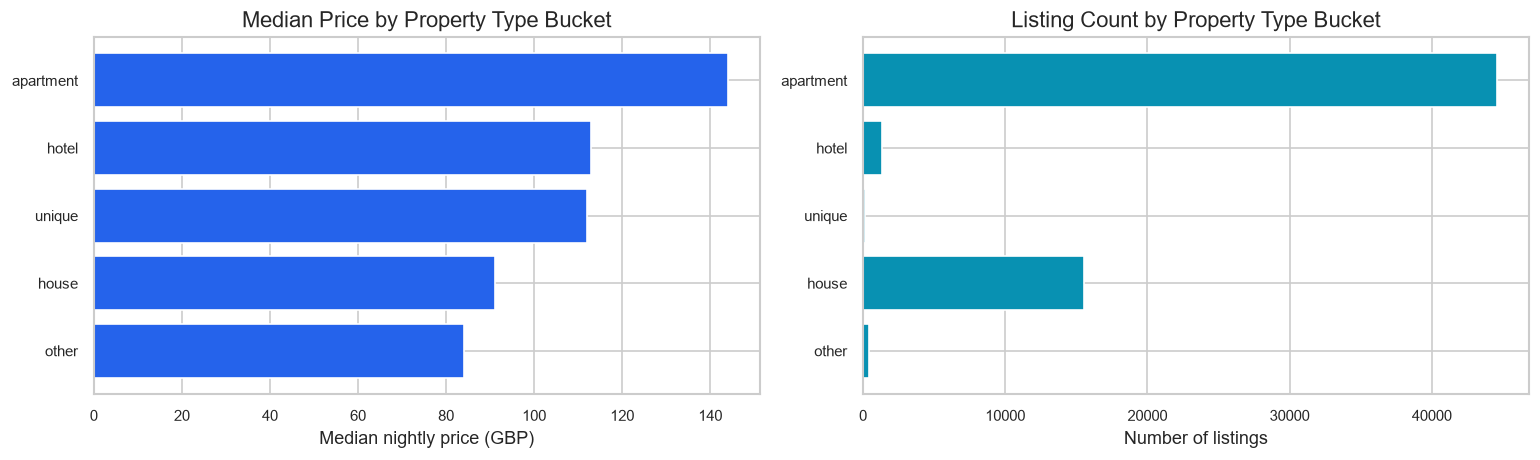

                      listing_count  median_price  mean_price
property_type_bucket                                         
other                           415          84.0       120.0
house                         15525          91.0       190.0
unique                          129         112.0       164.0
hotel                          1305         113.0       185.0
apartment                     44589         144.0       246.0


In [13]:
# ── Chart 4 — Price by property type bucket ──────────────────────────────────
# Use the 5-bucket coarsening (apartment/house/hotel/unique/other) rather than
# the raw 91-value property_type, which is too granular to visualise cleanly.

price_by_prop = (
    eda.groupby("property_type_bucket")["price_numeric"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .sort_values("median_price", ascending=True)   # ascending for horizontal bar
    .round(0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Median price bar (horizontal — easier to read labels)
axes[0].barh(price_by_prop.index, price_by_prop["median_price"], color="#2563eb")
axes[0].set_title("Median Price by Property Type Bucket")
axes[0].set_xlabel("Median nightly price (GBP)")

# Listing count bar to show relative sample sizes
axes[1].barh(price_by_prop.index, price_by_prop["listing_count"], color="#0891b2")
axes[1].set_title("Listing Count by Property Type Bucket")
axes[1].set_xlabel("Number of listings")

plt.tight_layout()
plt.savefig(FIGS / "03_price_by_property_type.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_prop.to_string())

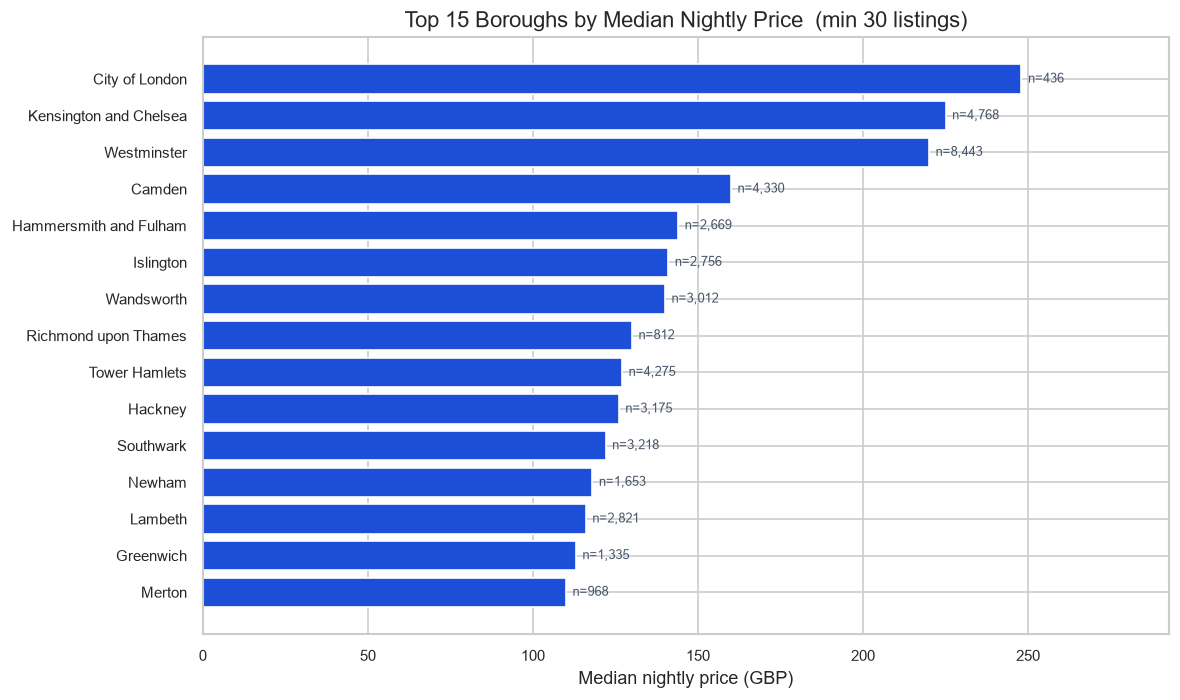

                        listing_count  median_price  mean_price
neighbourhood_cleansed                                         
City of London                    436         248.0       354.0
Kensington and Chelsea           4768         225.0       336.0
Westminster                      8443         220.0       342.0
Camden                           4330         160.0       217.0
Hammersmith and Fulham           2669         144.0       199.0
Islington                        2756         141.0       218.0
Wandsworth                       3012         140.0       198.0
Richmond upon Thames              812         130.0       184.0
Tower Hamlets                    4275         127.0       431.0
Hackney                          3175         126.0       161.0
Southwark                        3218         122.0       174.0
Newham                           1653         118.0       155.0
Lambeth                          2821         116.0       346.0
Greenwich                        1335   

In [14]:
# ── Chart 5 — Median price by neighbourhood (top 15) ─────────────────────────
# Minimum 30 listings per borough before ranking, so small-sample boroughs
# don't distort the comparison.

neigh_price = (
    eda.groupby("neighbourhood_cleansed")["price_numeric"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .query("listing_count >= 30")
    .sort_values("median_price", ascending=True)   # ascending for horizontal bar
    .tail(15)                                       # top 15 by median
    .round(0)
)
neigh_price.to_csv(TABLES / "price_by_neighbourhood.csv")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(neigh_price.index, neigh_price["median_price"], color="#1d4ed8")

# Label each bar with the listing count so the reader can judge reliability
for bar, (_, row) in zip(bars, neigh_price.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['listing_count']):,}", va="center", fontsize=8, color="#475569")

ax.set_title("Top 15 Boroughs by Median Nightly Price  (min 30 listings)")
ax.set_xlabel("Median nightly price (GBP)")
ax.set_xlim(0, neigh_price["median_price"].max() * 1.18)
plt.tight_layout()
plt.savefig(FIGS / "04_median_price_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

print(neigh_price.sort_values("median_price", ascending=False).to_string())

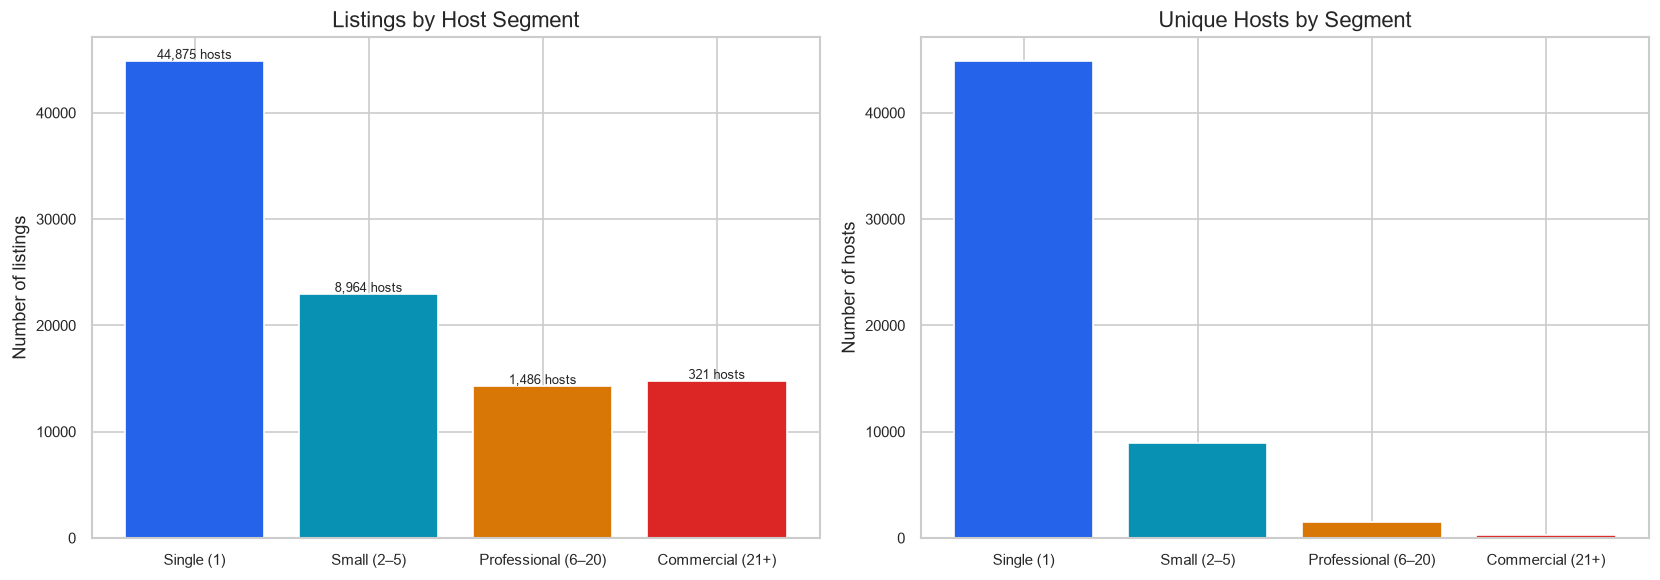

                     listing_count  unique_hosts  median_price  median_rating superhost_rate
host_segment                                                                                
Single (1)                   44875         44875         120.0           4.91       0.112141
Small (2–5)                  22950          8964         110.0           4.84       0.284429
Professional (6–20)          14280          1486         155.0           4.71       0.259453
Commercial (21+)             14766           321         184.0           4.64       0.156237


In [15]:
# ── Charts 6 & 7 — Host portfolio distribution and market concentration ───────
# Segments hosts by how many listings they operate.
# Market concentration shows what share of the total supply a minority holds.

def _host_segment(n: int) -> str:
    # Four buckets from the EDA plan section 9
    if n == 1:    return "Single (1)"
    if n <= 5:    return "Small (2–5)"
    if n <= 20:   return "Professional (6–20)"
    return "Commercial (21+)"

# Apply segment to the full listings df (not just price-eligible)
listings["host_segment"] = listings["host_portfolio_size"].apply(_host_segment)

seg_order = ["Single (1)", "Small (2–5)", "Professional (6–20)", "Commercial (21+)"]
seg_colors = ["#2563eb", "#0891b2", "#d97706", "#dc2626"]

host_seg = (
    listings.groupby("host_segment")
    .agg(
        listing_count=("id", "count"),
        unique_hosts=("host_id", "nunique"),
        median_price=("price_numeric", "median"),
        median_rating=("review_scores_rating", "median"),
        median_occupancy=("occupancy_proxy", "median"),
        median_availability=("availability_365", "median"),
        superhost_rate=("host_is_superhost", "mean"),
    )
    .reindex(seg_order)
    .round(2)
)
host_seg.to_csv(TABLES / "host_segment_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 6: listings by segment (shows supply concentration)
axes[0].bar(seg_order, host_seg["listing_count"], color=seg_colors)
axes[0].set_title("Listings by Host Segment")
axes[0].set_ylabel("Number of listings")
# Annotate each bar with host count for context
for i, (seg, row) in enumerate(host_seg.iterrows()):
    axes[0].text(i, row["listing_count"] + 200,
                 f"{int(row['unique_hosts']):,} hosts", ha="center", fontsize=8)

# Chart 7: unique hosts by segment (shows how many hosts each segment has)
axes[1].bar(seg_order, host_seg["unique_hosts"], color=seg_colors)
axes[1].set_title("Unique Hosts by Segment")
axes[1].set_ylabel("Number of hosts")

plt.tight_layout()
plt.savefig(FIGS / "05_host_portfolio_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(host_seg[["listing_count","unique_hosts","median_price","median_rating","superhost_rate"]].to_string())

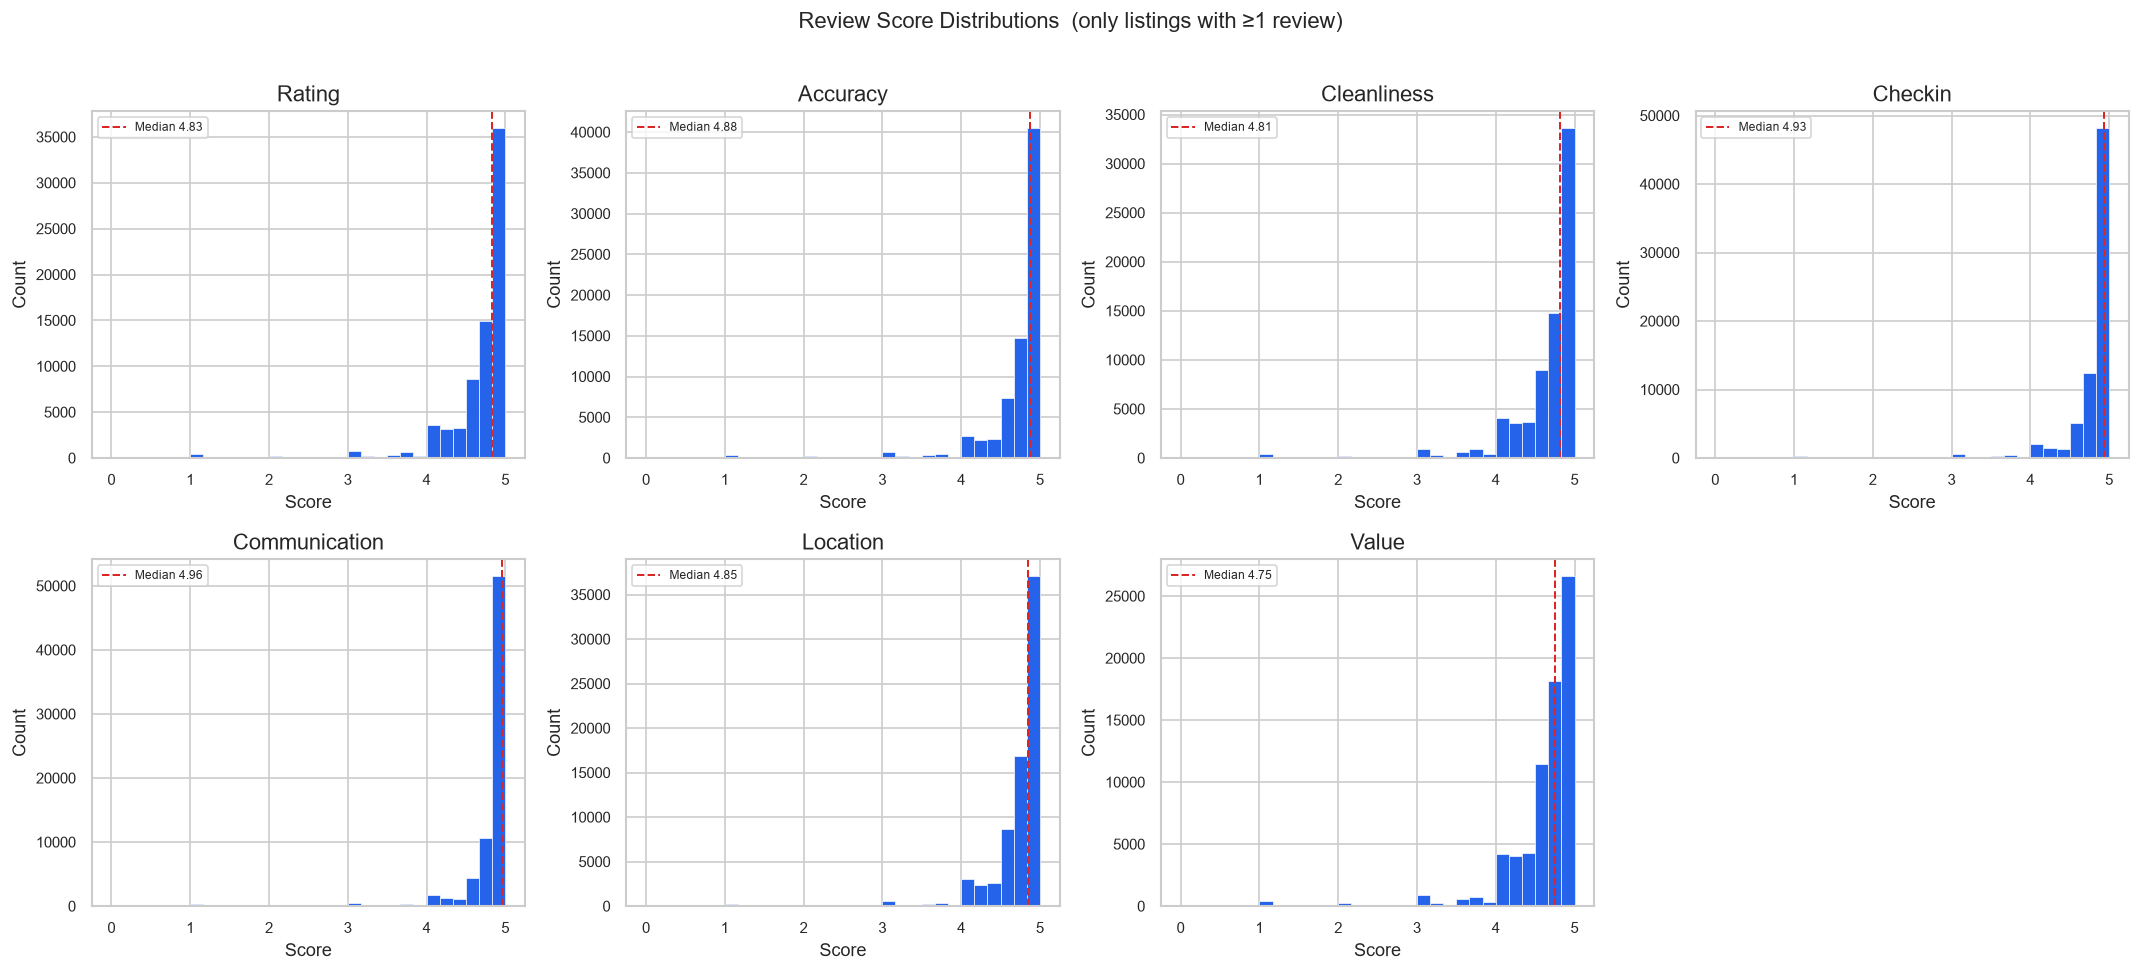

Review score summary:
       review_scores_rating  review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  review_scores_communication  review_scores_location  review_scores_value
count              72749.00                72734.00                   72740.00               72706.00                     72729.00                72705.00             72705.00
mean                   4.68                    4.73                       4.65                   4.79                         4.81                    4.73                 4.62
std                    0.49                    0.48                       0.52                   0.43                         0.43                    0.41                 0.51
min                    0.00                    0.00                       0.00                   0.00                         0.00                    0.00                 0.00
25%                    4.58                    4.67                       4.51                   4

In [16]:
# ── Chart 8 — Review score distributions ─────────────────────────────────────
# Shows how ratings cluster. Right-skew (most listings near 5) is typical;
# the long left tail is what matters for quality filtering later.

score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]
# Only plot columns that exist in the loaded dataframe
available_score_cols = [c for c in score_cols if c in listings.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(available_score_cols):
    s = listings[col].dropna()
    axes[i].hist(s, bins=30, color="#2563eb", edgecolor="white", linewidth=0.4)
    label = col.replace("review_scores_", "").replace("_", " ").title()
    axes[i].set_title(label)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")
    # Red median line so the mode-vs-median gap is obvious
    axes[i].axvline(s.median(), color="#dc2626", linestyle="--", linewidth=1.2,
                    label=f"Median {s.median():.2f}")
    axes[i].legend(fontsize=7)

# Hide the unused 8th subplot
for j in range(len(available_score_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Review Score Distributions  (only listings with ≥1 review)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "06_review_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Review score summary:")
print(listings[available_score_cols].describe().round(2).to_string())

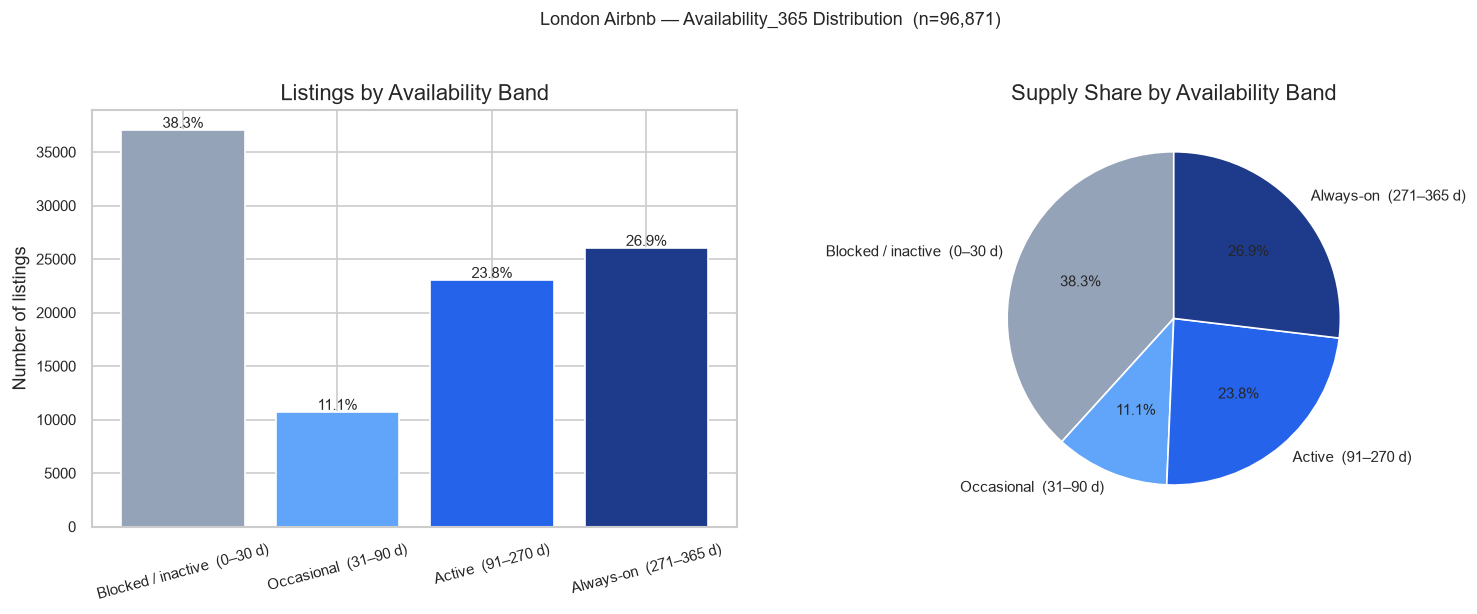

                        band  listing_count  share_pct  median_price  median_occupancy
Blocked / inactive  (0–30 d)          37067       38.3         131.0          1.000000
       Occasional  (31–90 d)          10717       11.1         118.0          0.810959
          Active  (91–270 d)          23045       23.8         134.0          0.479452
      Always-on  (271–365 d)          26042       26.9         145.0          0.049315


In [17]:
# ── Chart 9 — Availability band distribution ─────────────────────────────────
# Availability_365 (from the listings snapshot) shows how open each listing is.
# Four bands map naturally to host intent: blocked/inactive → casual → active → always-on.
# Uses full listings DataFrame (all 96k rows), not just price-eligible.

def _avail_band(days: int) -> str:
    if days <= 30:   return "Blocked / inactive  (0–30 d)"
    if days <= 90:   return "Occasional  (31–90 d)"
    if days <= 270:  return "Active  (91–270 d)"
    return "Always-on  (271–365 d)"

listings["avail_band"] = listings["availability_365"].apply(_avail_band)

band_order = [
    "Blocked / inactive  (0–30 d)",
    "Occasional  (31–90 d)",
    "Active  (91–270 d)",
    "Always-on  (271–365 d)",
]
band_colors = ["#94a3b8", "#60a5fa", "#2563eb", "#1e3a8a"]

band_counts = listings["avail_band"].value_counts().reindex(band_order)
band_pct    = (band_counts / len(listings) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: absolute listing count per band
axes[0].bar(band_order, band_counts.values, color=band_colors)
axes[0].set_title("Listings by Availability Band")
axes[0].set_ylabel("Number of listings")
axes[0].tick_params(axis="x", labelrotation=15)
for i, (cnt, pct) in enumerate(zip(band_counts.values, band_pct.values)):
    axes[0].text(i, cnt + 200, f"{pct}%", ha="center", fontsize=9)

# Pie chart: share of supply by band
axes[1].pie(band_counts.values, labels=band_order, colors=band_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
axes[1].set_title("Supply Share by Availability Band")

plt.suptitle("London Airbnb — Availability_365 Distribution  (n=96,871)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "07_availability_bands.png", dpi=150, bbox_inches="tight")
plt.show()

# Save summary table
avail_summary = pd.DataFrame({
    "band": band_order,
    "listing_count": band_counts.values,
    "share_pct": band_pct.values,
    "median_price": [
        listings.loc[listings["avail_band"] == b, "price_numeric"].median()
        for b in band_order
    ],
    "median_occupancy": [
        listings.loc[listings["avail_band"] == b, "occupancy_proxy"].median()
        for b in band_order
    ],
})
avail_summary.to_csv(TABLES / "availability_band_summary.csv", index=False)

print(avail_summary.to_string(index=False))

---
## Step 3 — Geographic and Spatial Analysis

Covers: listing density by borough (listings per km²), price gradient vs distance
from city centre, median review score choropleth, and room-type clustering.

GeoJSON boundary file: `data/raw/london/neighbourhoods.geojson` (33 boroughs, EPSG:4326).  
Area calculations reprojected to EPSG:27700 (British National Grid) for metric accuracy.

In [18]:
# ── 7.1 + 7.2 — Validate coordinates and load neighbourhood boundaries ────────
# Drop the tiny fraction of listings with impossible lat/lon before any spatial work.

geo_listings = listings[
    listings["latitude"].between(-90, 90)
    & listings["longitude"].between(-180, 180)
    & listings["latitude"].notna()
    & listings["longitude"].notna()
].copy()

print(f"Coordinate-valid listings: {len(geo_listings):,}  "
      f"(dropped {len(listings) - len(geo_listings)} with bad/missing coords)")

# Load borough polygon boundaries
boroughs = gpd.read_file(RAW / "neighbourhoods.geojson")  # EPSG:4326, 33 rows
print(f"Borough polygons loaded: {len(boroughs)} — CRS: {boroughs.crs}")

# Convert listing lat/lon to geometry points (same CRS as boroughs)
listing_points = gpd.GeoDataFrame(
    geo_listings,
    geometry=gpd.points_from_xy(geo_listings["longitude"], geo_listings["latitude"]),
    crs="EPSG:4326",
)

# Reproject boroughs to EPSG:27700 (British National Grid) for area in metres
# EPSG:27700 is the correct metric projection for Great Britain (D-018)
boroughs_bng = boroughs.to_crs("EPSG:27700")
boroughs_bng["area_km2"] = (boroughs_bng.geometry.area / 1e6).round(3)

print("\nBorough area sample (km²):")
print(boroughs_bng[["neighbourhood", "area_km2"]].sort_values("area_km2", ascending=False).head(8).to_string(index=False))

Coordinate-valid listings: 96,871  (dropped 0 with bad/missing coords)
Borough polygons loaded: 33 — CRS: EPSG:4326

Borough area sample (km²):
       neighbourhood  area_km2
             Bromley   150.135
          Hillingdon   115.704
            Havering   112.352
              Barnet    86.750
             Croydon    86.496
             Enfield    82.202
              Bexley    60.581
Richmond upon Thames    57.355


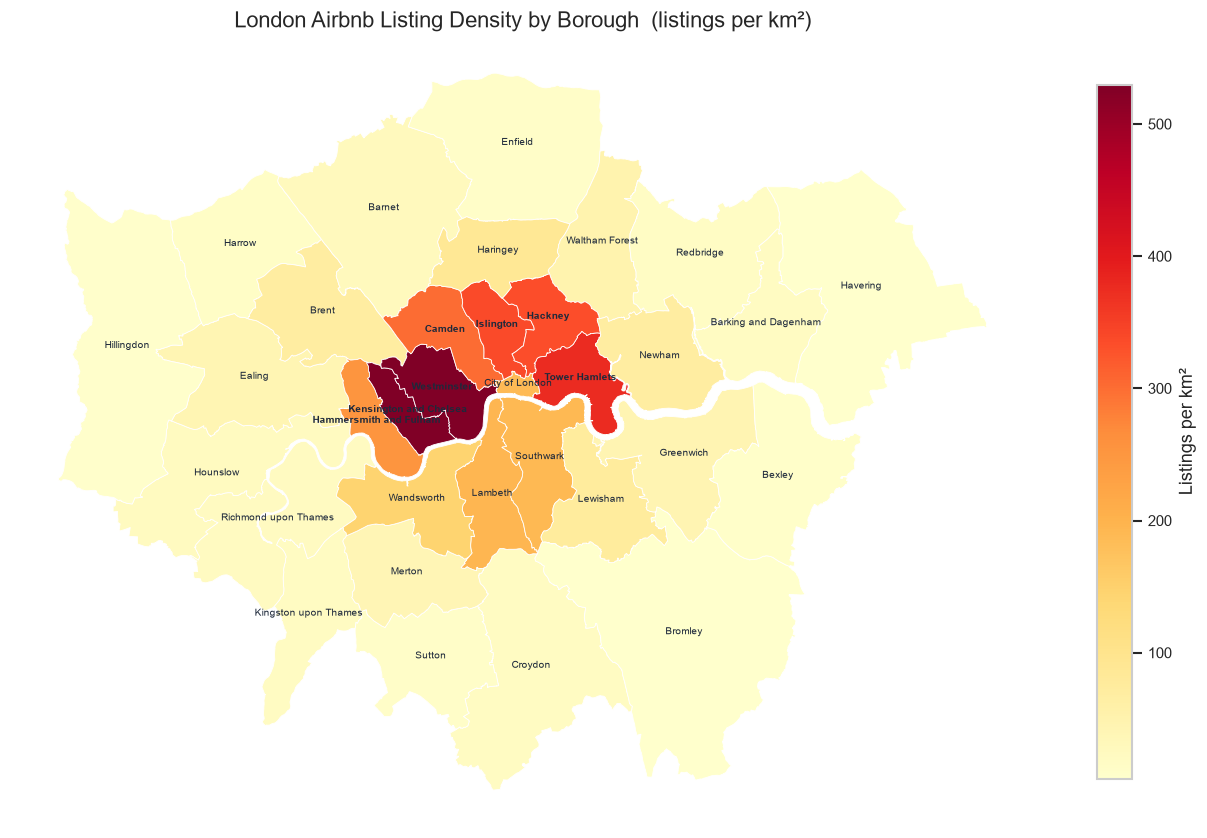

Top 10 boroughs by density:
         neighbourhood  listing_count  area_km2  listings_per_km2
           Westminster          11385    21.488             529.8
Kensington and Chelsea           6401    12.124             528.0
         Tower Hamlets           7469    19.779             377.6
             Islington           5036    14.857             339.0
               Hackney           6359    19.050             333.8
                Camden           6551    21.790             300.6
Hammersmith and Fulham           4157    16.398             253.5
               Lambeth           5190    26.811             193.6
             Southwark           5475    28.863             189.7
        City of London            549     2.904             189.0


In [19]:
# ── Chart 10 — Listing density choropleth (listings per km²) ─────────────────
# Raw listing counts favour large boroughs; density normalises by area.
# Join on: listings["neighbourhood_cleansed"] ↔ boroughs["neighbourhood"]

listing_count_by_borough = (
    geo_listings.groupby("neighbourhood_cleansed")
    .agg(listing_count=("id", "count"), unique_hosts=("host_id", "nunique"))
    .reset_index()
    .rename(columns={"neighbourhood_cleansed": "neighbourhood"})
)

density_gdf = boroughs_bng.merge(listing_count_by_borough, on="neighbourhood", how="left")
density_gdf["listings_per_km2"] = (
    density_gdf["listing_count"] / density_gdf["area_km2"]
).round(1)

density_gdf.to_file(  # overwrite-safe: produces GeoJSON, not the source file
    str(TABLES / "neighbourhood_density.csv").replace(".csv", ".geojson"),
    driver="GeoJSON"
)
# Also save a flat CSV for the API / report
density_gdf.drop(columns="geometry").to_csv(TABLES / "neighbourhood_density.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 10))
density_gdf.plot(
    column="listings_per_km2",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Listings per km²", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "#e2e8f0", "label": "No data"},
)

# Label each borough centroid with its name
for _, row in density_gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(row["neighbourhood"], xy=(cx, cy),
                ha="center", fontsize=6, color="#1e293b",
                fontweight="bold" if row["listings_per_km2"] > 200 else "normal")

ax.set_title("London Airbnb Listing Density by Borough  (listings per km²)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "08_listing_density_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 boroughs by density:")
print(density_gdf[["neighbourhood","listing_count","area_km2","listings_per_km2"]]
      .sort_values("listings_per_km2", ascending=False).head(10).to_string(index=False))

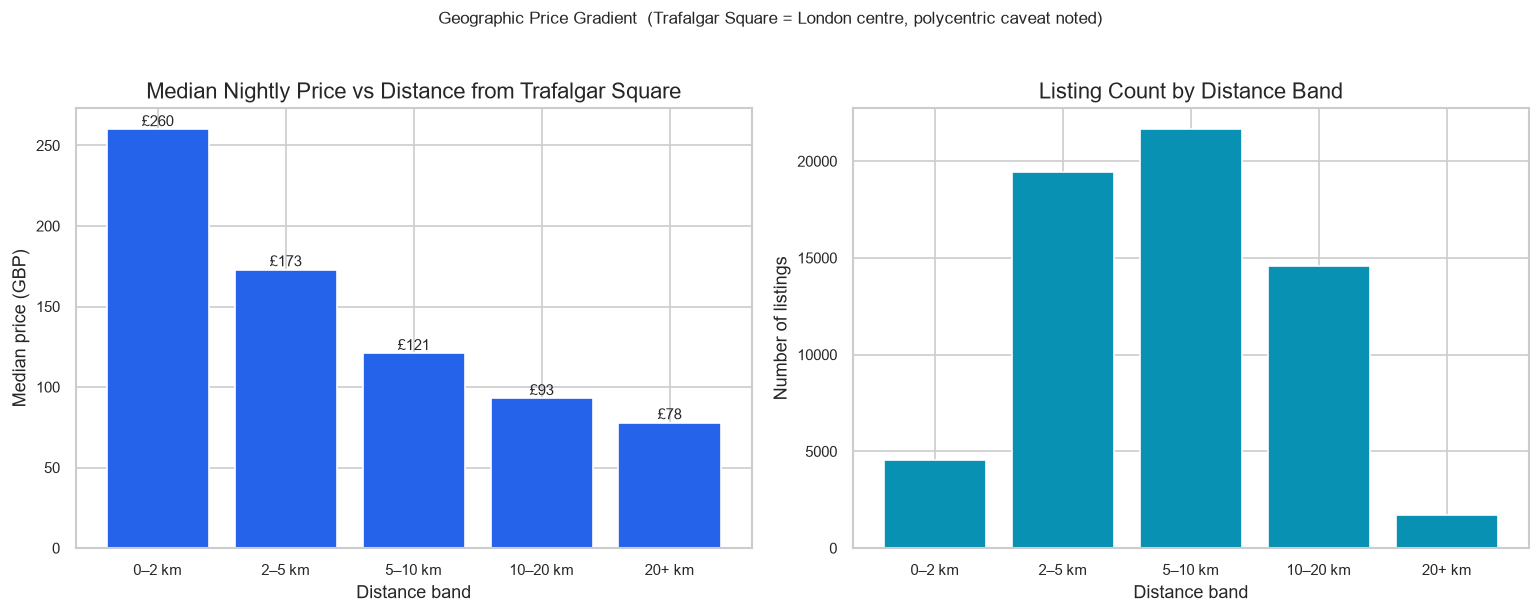

           listing_count  median_price  mean_price    p75
dist_band                                                
0–2 km              4551         260.0       470.0  396.0
2–5 km             19457         173.0       262.0  278.0
5–10 km            21645         121.0       225.0  190.0
10–20 km           14603          93.0       131.0  153.0
20+ km              1707          78.0       124.0  137.0


In [20]:
# ── Chart 11 — Price gradient by distance from city centre ───────────────────
# City centre = Trafalgar Square (well-documented single reference, acknowledged limitation).
# Limitation: London is polycentric; a single point oversimplifies, but is standard.

import math

CENTRE_LAT = 51.5080   # Trafalgar Square
CENTRE_LON = -0.1281

def _haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance in km."""
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

geo_listings["dist_km"] = geo_listings.apply(
    lambda r: _haversine_km(r["latitude"], r["longitude"], CENTRE_LAT, CENTRE_LON),
    axis=1,
)

def _dist_band(d: float) -> str:
    if d <= 2:   return "0–2 km"
    if d <= 5:   return "2–5 km"
    if d <= 10:  return "5–10 km"
    if d <= 20:  return "10–20 km"
    return "20+ km"

geo_listings["dist_band"] = geo_listings["dist_km"].apply(_dist_band)

band_order_dist = ["0–2 km", "2–5 km", "5–10 km", "10–20 km", "20+ km"]

price_by_dist = (
    geo_listings[geo_listings["price_numeric"].notna()]
    .groupby("dist_band", observed=True)["price_numeric"]
    .agg(
        listing_count="count",
        median_price="median",
        mean_price="mean",
        p75=lambda x: x.quantile(0.75),
    )
    .reindex(band_order_dist)
    .round(0)
)
price_by_dist.to_csv(TABLES / "price_by_distance_band.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(price_by_dist.index, price_by_dist["median_price"], color="#2563eb")
axes[0].set_title("Median Nightly Price vs Distance from Trafalgar Square")
axes[0].set_xlabel("Distance band")
axes[0].set_ylabel("Median price (GBP)")
for i, (idx, row) in enumerate(price_by_dist.iterrows()):
    axes[0].text(i, row["median_price"] + 2, f"£{int(row['median_price'])}", ha="center", fontsize=9)

axes[1].bar(price_by_dist.index, price_by_dist["listing_count"], color="#0891b2")
axes[1].set_title("Listing Count by Distance Band")
axes[1].set_xlabel("Distance band")
axes[1].set_ylabel("Number of listings")

plt.suptitle("Geographic Price Gradient  (Trafalgar Square = London centre, polycentric caveat noted)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "09_price_gradient_by_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_dist.to_string())

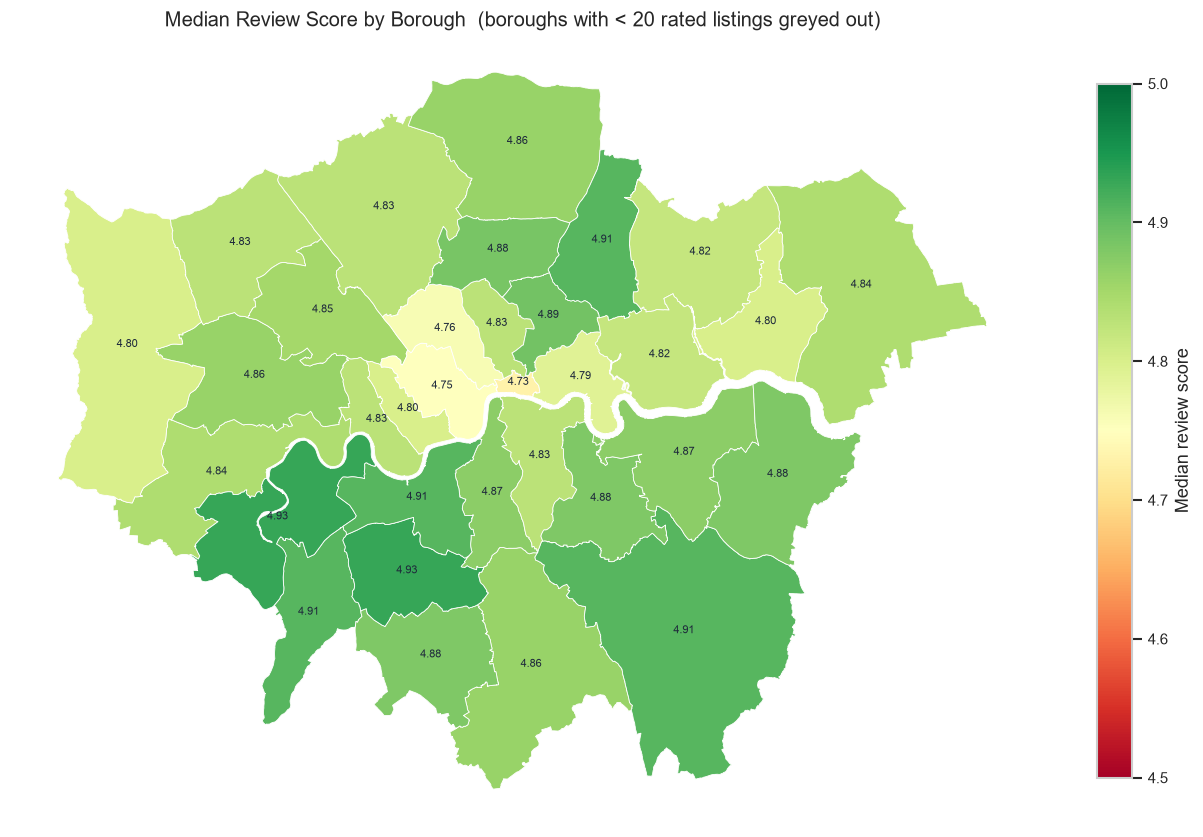

         neighbourhood  rated_listing_count  median_rating  mean_rating
  Richmond upon Thames                  985          4.930     4.814264
                Merton                 1128          4.930     4.785860
  Kingston upon Thames                  548          4.910     4.777464
               Bromley                  653          4.910     4.774824
        Waltham Forest                 1422          4.910     4.756646
            Wandsworth                 3700          4.910     4.773305
               Hackney                 4906          4.890     4.763106
              Haringey                 1928          4.885     4.735156
                Sutton                  336          4.880     4.726250
                Bexley                  429          4.880     4.735688
              Lewisham                 2018          4.880     4.721601
             Greenwich                 1519          4.870     4.691145
               Lambeth                 4050          4.870     4

In [21]:
# ── Chart 12 — Median review score choropleth by borough ─────────────────────
# Plan requirement: min 20 rated listings per borough before including in map.
# Boroughs below threshold are shown in grey.

rating_by_borough = (
    listings.groupby("neighbourhood_cleansed")
    .agg(
        rated_listing_count=("review_scores_rating", "count"),
        median_rating=("review_scores_rating", "median"),
        mean_rating=("review_scores_rating", "mean"),
    )
    .reset_index()
    .rename(columns={"neighbourhood_cleansed": "neighbourhood"})
)

# Mask boroughs with fewer than 20 rated listings (too noisy to interpret)
rating_by_borough.loc[rating_by_borough["rated_listing_count"] < 20, "median_rating"] = None

rating_gdf = boroughs_bng.merge(rating_by_borough, on="neighbourhood", how="left")

fig, ax = plt.subplots(figsize=(11, 10))
rating_gdf.plot(
    column="median_rating",
    cmap="RdYlGn",          # red = low rating, green = high
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Median review score", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "#e2e8f0", "label": "< 20 rated listings"},
    vmin=4.5, vmax=5.0,     # compress the range — scores cluster near 5
)

for _, row in rating_gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    if pd.notna(row.get("median_rating")):
        ax.annotate(f"{row['median_rating']:.2f}", xy=(cx, cy),
                    ha="center", fontsize=6.5, color="#1e293b")

ax.set_title("Median Review Score by Borough  (boroughs with < 20 rated listings greyed out)",
             fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "10_review_score_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(rating_by_borough.sort_values("median_rating", ascending=False).to_string(index=False))

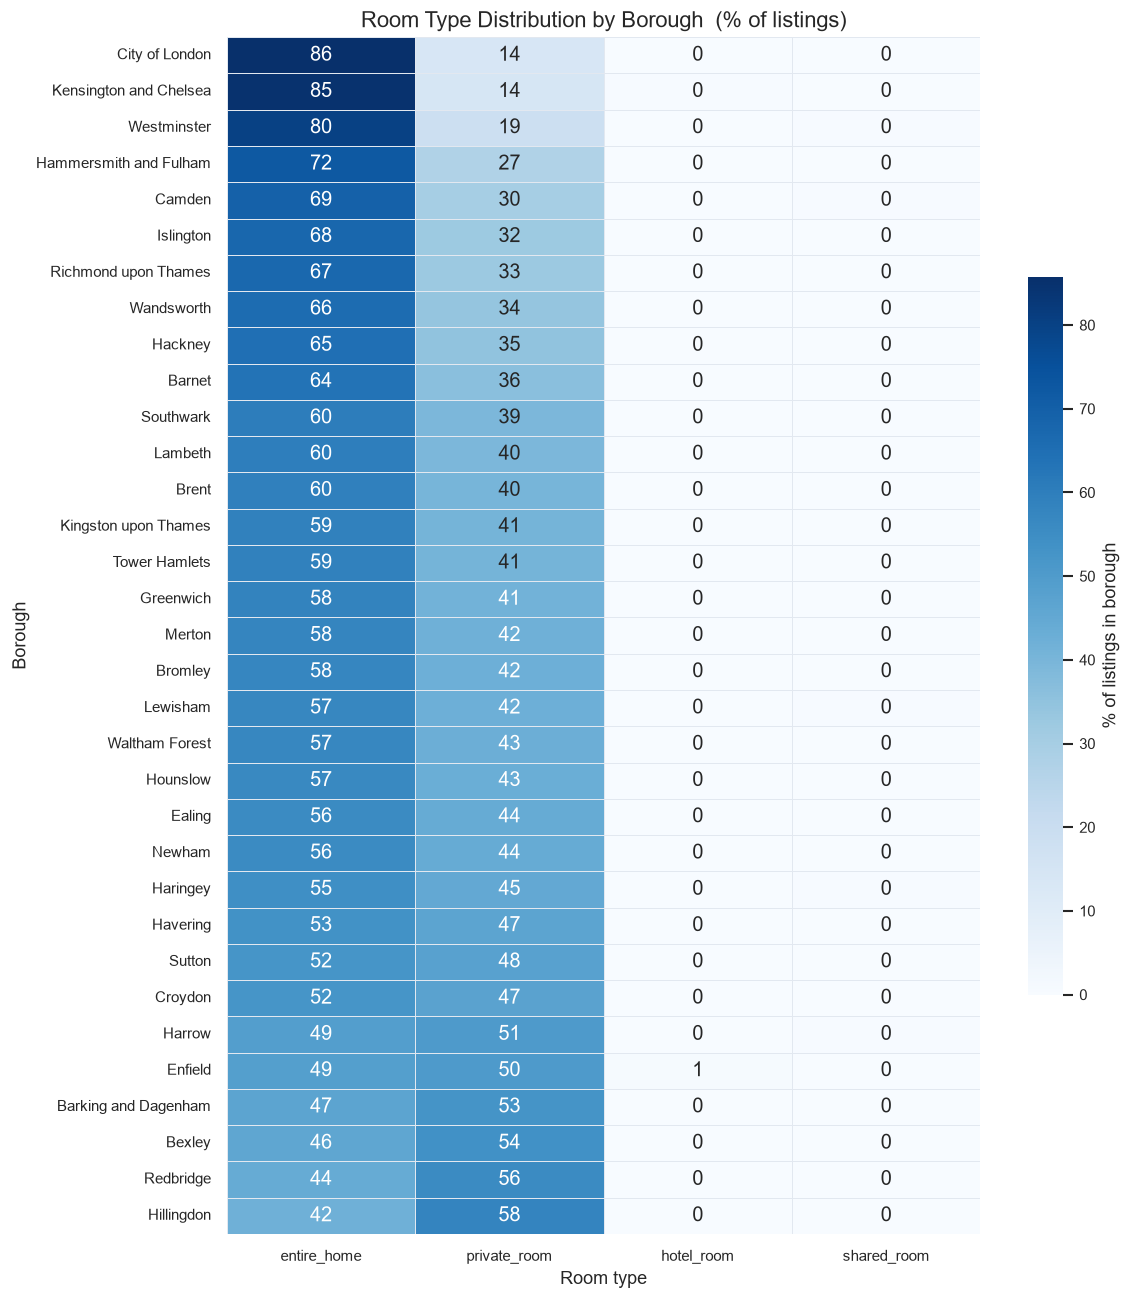

Top 5 entire-home boroughs:
neighbourhood_cleansed
City of London            85.8
Kensington and Chelsea    85.0
Westminster               80.4
Hammersmith and Fulham    72.3
Camden                    69.4


In [22]:
# ── Chart 13 — Room-type clustering by neighbourhood (heatmap) ───────────────
# Shows where entire homes, private rooms, etc. concentrate.
# Normalised to % of listings in each borough so borough size doesn't dominate.

room_type_pct = pd.crosstab(
    listings["neighbourhood_cleansed"],
    listings["room_type"],
    normalize="index",
) * 100

room_type_pct = room_type_pct.round(1)
room_type_pct.to_csv(TABLES / "room_type_by_neighbourhood.csv")

# Sort boroughs by entire_home share descending for a natural reading order
col_order = ["entire_home", "private_room", "hotel_room", "shared_room"]
col_order = [c for c in col_order if c in room_type_pct.columns]
room_type_pct = room_type_pct[col_order]
room_type_pct = room_type_pct.sort_values("entire_home", ascending=False)

fig, ax = plt.subplots(figsize=(10, 11))
sns.heatmap(
    room_type_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.4,
    linecolor="#e2e8f0",
    cbar_kws={"label": "% of listings in borough", "shrink": 0.6},
    ax=ax,
)
ax.set_title("Room Type Distribution by Borough  (% of listings)", fontsize=13)
ax.set_xlabel("Room type")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.savefig(FIGS / "11_room_type_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 entire-home boroughs:")
print(room_type_pct["entire_home"].sort_values(ascending=False).head(5).to_string())